# Euler–Bernoulli Beam FEM — Didactic Notebook

This notebook constructs a minimal but educational **Euler–Bernoulli beam** solver with the classic **2-node Hermite cubic element** (DOFs per node: transverse deflection $w$ and rotation $\theta=w'$). We’ll go in tiny chunks so each step is clear.

**You will learn**
- The strong form and the classic **cantilever with tip load** test.
- Hermite cubic **shape functions** $N_i(\xi)$ and the curvature operator $B(\xi)$ so that $\kappa=w''=B\,u_e$.
- How to build the **element stiffness** $k_e=\int B^\top EI\,B\,dx$ and **consistent loads**.
- Assembly, boundary conditions, solution, and comparison with the analytical result.

> Note: In VS Code notebooks, use `$...$` for inline math and `$$...$$` for display math.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Simple, readable plotting
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

def pretty(x, name="array"):
    x = np.asarray(x)
    print(f"{name} shape={x.shape}\n{x}\n")


## 1) Strong form, assumptions, boundary conditions, and an analytical check

### 1.1 Euler–Bernoulli beam assumptions
- **Kinematics:** cross-sections remain plane and normal to the deformed centerline (no shear deformation).
- **Small strains & small rotations:** linearization is valid.
- **Material:** linear elastic, homogeneous (for now).
- **Geometry:** prismatic (constant $E$ and $I$ over the element), unless stated otherwise.

### 1.2 Unknown and loading
- Transverse deflection: $w(x)$ (positive in the chosen transverse direction).
- Distributed transverse load: $q(x)$ (same sign convention as $w$).
- Bending curvature: $\kappa(x) = w''(x)$ (prime $'$ denotes $d/dx$).
- Bending moment: $M(x) = E I\, \kappa(x) = E I\,w''(x)$.
- Shear force: $V(x) = M'(x) = E I\, w'''(x)$.

### 1.3 Governing differential equation (4th order)
$$
E I\, w''''(x) = q(x), \qquad x \in (0,L).
$$

### 1.4 Boundary conditions (examples)
Because the ODE is 4th order, we need four independent boundary conditions (BCs).

- **Clamped (built-in) at $x=0$:**  
  $w(0)=0,\quad w'(0)=0.$
- **Free end at $x=L$ with a tip force $P$:**  
  $M(L)=E I\, w''(L)=0,\quad V(L)=E I\, w'''(L)=P.$
- Other possibilities: simply-supported, fixed–fixed, etc. (not used here).

### 1.5 Analytical solution (cantilever with tip load $P$ at $x=L$)
For constant $(E,I)$ and $q(x)\equiv 0$ with a tip point load $P$:
$$
w(x) = \frac{P}{6 E I}\, x^2(3L - x), \qquad
\theta(x)=w'(x)=\frac{P}{2 E I}\, x(2L - x),
$$
$$
w(L) = \frac{P L^3}{3 E I}, \qquad \theta(L) = \frac{P L^2}{2 E I}, \qquad
M(L)=0,\quad V(L)=P.
$$

These formulas will serve as **ground truth** to verify our FEM implementation.


## 2) Weak form and regularity (why Hermite $C^1$ elements)

Let $v(x)$ be an admissible test (virtual deflection), with the same essential BCs as $w(x)$.
Multiply the strong form by $v$ and integrate over $(0,L)$:
$$
\int_0^L E I\, w''''\, v \, dx = \int_0^L q\, v \, dx.
$$

Integrate by parts **twice** to lower derivatives on $w$ (and expose natural BC terms):
$$
\int_0^L E I\, w''\, v'' \, dx
\;+\; \underbrace{\big[ E I\,w''\,v' \big]_0^L}_{\text{bending moment term}}
\;-\; \underbrace{\big[ E I\,w''' \, v \big]_0^L}_{\text{shear term}}
\;=\; \int_0^L q\, v\, dx.
$$

Interpreting boundary terms with $M=E I\,w''$ and $V = E I\,w'''$:
- If $M$ and $V$ are **prescribed** at a boundary, they appear on the **right-hand side** as external work.
- If $w$ and $w'$ are **prescribed** (clamped), $v=0$ and $v'=0$ there, and the boundary terms vanish.

**Bilinear form** and **linear functional** (for the clamped–free cantilever with tip force $P$ at $L$):
$$
a(w,v) := \int_0^L E I\, w''\, v''\, dx,
\qquad
\ell(v) := \int_0^L q\, v\, dx \;+\; P\, v(L).
$$

**Weak problem:** Find $w \in \mathcal{V}$ such that
$$
a(w,v) = \ell(v) \quad \forall\, v \in \mathcal{V}_0,
$$
where $\mathcal{V}$ is the space of functions with $w$ and $w'$ continuous (i.e., $C^1$) and square-integrable $w''$ on $(0,L)$, with the essential BCs enforced ($w(0)=0$, $w'(0)=0$).  
**This $C^1$ requirement is why we use Hermite cubic elements** in a displacement-based FEM for Euler–Bernoulli beams.


## 3) Hermite cubic element: interpolation, mapping, and curvature operator

### 3.1 Element and mapping
Consider an element $e$ spanning $x\in[x_1, x_2]$ with length $L_e = x_2-x_1$.
Introduce a local coordinate $\xi \in [0,1]$ via the affine map:
$$
x(\xi) = x_1 + \xi\, L_e, \qquad \frac{d}{dx} = \frac{1}{L_e}\frac{d}{d\xi}.
$$

### 3.2 Element DOFs and interpolation
The 2-node Hermite beam element has **two DOFs per node**:
- at node 1 (left): transverse deflection $w_1$ and rotation $\theta_1=w'(x_1)$,
- at node 2 (right): transverse deflection $w_2$ and rotation $\theta_2=w'(x_2)$.

Collect them in 
$$
\mathbf{u}_e = [\, w_1,\ \theta_1,\ w_2,\ \theta_2 \,]^T.
$$

Interpolate the field $w(x)$ with **cubic Hermite shape functions** $N_i(\xi)$:
$$
w(\xi) = N_1(\xi)\, w_1 \;+\; N_2(\xi)\, \theta_1 \;+\; N_3(\xi)\, w_2 \;+\; N_4(\xi)\, \theta_2.
$$

### 3.3 Shape functions (on $\xi \in [0,1]$)
The polynomials are uniquely determined by the nodal interpolation constraints
$$
\begin{aligned}
&N_1(0)=1,\ N_1'(0)=0,\ N_1(1)=0,\ N_1'(1)=0,\\
&N_2(0)=0,\ N_2'(0)=1,\ N_2(1)=0,\ N_2'(1)=0,\\
&N_3(0)=0,\ N_3'(0)=0,\ N_3(1)=1,\ N_3'(1)=0,\\
&N_4(0)=0,\ N_4'(0)=0,\ N_4(1)=0,\ N_4'(1)=1,
\end{aligned}
$$
where the primes here denote derivatives **with respect to $x$**. Accounting for $d/dx=(1/L_e)\,d/d\xi$, the explicit forms are
$$
\begin{aligned}
N_1(\xi) &= 1 - 3\xi^2 + 2\xi^3, \\
N_2(\xi) &= L_e(\xi - 2\xi^2 + \xi^3), \\
N_3(\xi) &= 3\xi^2 - 2\xi^3, \\
N_4(\xi) &= L_e(-\xi^2 + \xi^3).
\end{aligned}
$$

Sanity check of interpolation:
- $w(0)=w_1$, $w(1)=w_2$,
- $w'(0)=\theta_1$, $w'(1)=\theta_2$.

### 3.4 Curvature (bending strain) and the $B$-operator
The curvature is $\kappa = w''(x)$. Using $d^2/dx^2 = (1/L_e^2)\,d^2/d\xi^2$:
$$
\frac{d^2}{d\xi^2}\big[\,N_1,\,N_2,\,N_3,\,N_4\,\big]
= \big[\, -6+12\xi,\; (-4+6\xi)L_e,\; 6-12\xi,\; (-2+6\xi)L_e \,\big].
$$
Therefore,
$$
\boxed{
B(\xi) = \begin{bmatrix}
\frac{-6+12\xi}{L_e^2} &
\frac{-4+6\xi}{L_e} &
\frac{6-12\xi}{L_e^2} &
\frac{-2+6\xi}{L_e}
\end{bmatrix}
\quad \text{such that}\quad
\kappa(\xi)=w''(x)= B(\xi)\, \mathbf{u}_e.
}
$$

> We will use $N(\xi) = [N_1, N_2, N_3, N_4]$ and $B(\xi)$ to build element matrices and load vectors.


In [9]:
import numpy as np

def hermite_shapes_and_derivatives(xi: float, Le: float):
    """
    Cubic Hermite shape functions and their derivatives on xi in [0,1].

    Parameters
    ----------
    xi : float
        Local coordinate in [0, 1].
    Le : float
        Element length (x2 - x1) > 0.

    Returns
    -------
    N : (4,) ndarray
        Shape functions [N1, N2, N3, N4].
    dNdx : (4,) ndarray
        First derivatives dN_i/dx evaluated at xi.
    d2Ndx2 : (4,) ndarray
        Second derivatives d2N_i/dx^2 evaluated at xi.
    B : (4,) ndarray
        Curvature operator row so that w'' = B @ u_e for u_e=[w1,th1,w2,th2].
        By construction, B == d2Ndx2.
    """
    # -- shape functions on [0,1]
    N1 = 1 - 3*xi**2 + 2*xi**3
    N2 = Le * (xi - 2*xi**2 + xi**3)
    N3 = 3*xi**2 - 2*xi**3
    N4 = Le * (-xi**2 + xi**3)
    N  = np.array([N1, N2, N3, N4], dtype=float)

    # d/dx = (1/Le) d/dxi
    dN1_dxi = -6*xi + 6*xi**2
    dN2_dxi = Le * (1 - 4*xi + 3*xi**2)
    dN3_dxi =  6*xi - 6*xi**2
    dN4_dxi = Le * (-2*xi + 3*xi**2)
    dNdx = np.array([dN1_dxi/Le, dN2_dxi/Le, dN3_dxi/Le, dN4_dxi/Le], dtype=float)

    # d2/dx2 = (1/Le^2) d2/dxi^2 ; careful with leading Le in N2, N4
    d2N1_dxi2 = -6 + 12*xi
    d2N2_dxi2 = -4 + 6*xi      # corrected
    d2N3_dxi2 =  6 - 12*xi
    d2N4_dxi2 = -2 + 6*xi
    d2Ndx2 = np.array([
        d2N1_dxi2/Le**2,
        d2N2_dxi2/Le,      # because N2 has a leading Le
        d2N3_dxi2/Le**2,
        d2N4_dxi2/Le       # because N4 has a leading Le
    ], dtype=float)

    B = d2Ndx2.copy()
    return N, dNdx, d2Ndx2, B


In [10]:
def check_hermite_end_values(Le=1.0, atol=1e-12):
    print("Sanity checks at element ends (xi=0 and xi=1):")
    for xi in [0.0, 1.0]:
        N, dNdx, d2Ndx2, B = hermite_shapes_and_derivatives(xi, Le)
        side = "left (xi=0)" if xi == 0.0 else "right (xi=1)"
        print(f"\n-- {side} --")
        print("N =", N)
        print("dN/dx =", dNdx)
        print("d2N/dx2 =", d2Ndx2)

    # Interpolation tests with an arbitrary u_e:
    # choose u_e = [w1, th1, w2, th2] and verify:
    # w(0)=w1, w'(0)=th1, w(1)=w2, w'(1)=th2
    u_e = np.array([0.7, -0.2, 1.3, 0.4])

    N0, dNdx0, *_ = hermite_shapes_and_derivatives(0.0, Le)
    N1, dNdx1, *_ = hermite_shapes_and_derivatives(1.0, Le)

    w0    = N0 @ u_e
    th0   = dNdx0 @ u_e
    w1    = N1 @ u_e
    th1   = dNdx1 @ u_e

    ok = (abs(w0 - u_e[0]) < atol and
          abs(th0 - u_e[1]) < atol and
          abs(w1 - u_e[2]) < atol and
          abs(th1 - u_e[3]) < atol)

    print("\nInterpolation check with u_e=[w1,th1,w2,th2] =", u_e)
    print(f"w(0)={w0:.12f} vs w1={u_e[0]:.12f}")
    print(f"w'(0)={th0:.12f} vs th1={u_e[1]:.12f}")
    print(f"w(1)={w1:.12f} vs w2={u_e[2]:.12f}")
    print(f"w'(1)={th1:.12f} vs th2={u_e[3]:.12f}")
    print("PASS" if ok else "FAIL")

check_hermite_end_values(Le=2.0)


Sanity checks at element ends (xi=0 and xi=1):

-- left (xi=0) --
N = [1. 0. 0. 0.]
dN/dx = [0. 1. 0. 0.]
d2N/dx2 = [-1.5 -2.   1.5 -1. ]

-- right (xi=1) --
N = [0. 0. 1. 0.]
dN/dx = [0. 0. 0. 1.]
d2N/dx2 = [ 1.5  1.  -1.5  2. ]

Interpolation check with u_e=[w1,th1,w2,th2] = [ 0.7 -0.2  1.3  0.4]
w(0)=0.700000000000 vs w1=0.700000000000
w'(0)=-0.200000000000 vs th1=-0.200000000000
w(1)=1.300000000000 vs w2=1.300000000000
w'(1)=0.400000000000 vs th2=0.400000000000
PASS


## 4) Element stiffness $k_e$: derivation and formulas

### 4.1 Energy and constitutive law
For Euler–Bernoulli bending under the assumptions listed before:
- Curvature (bending strain): $\kappa(x) = w''(x)$.
- Constitutive law: $M(x) = E I\, \kappa(x) = E I\, w''(x)$.
- Bending strain energy on an element $e$ of length $L_e$:
$$
\mathcal{U}_e = \frac{1}{2}\int_{x_1}^{x_2} M\,\kappa\, dx
= \frac{1}{2}\int_{0}^{L_e} (E I)\, (w'')^2\, dx.
$$

Using the Hermite interpolation and the curvature operator $B(\xi)$ such that $\kappa = w'' = B(\xi)\, \mathbf{u}_e$, and the affine map $x(\xi) = x_1 + \xi L_e$ with $dx = L_e\, d\xi$:
$$
\mathcal{U}_e = \frac{1}{2}\int_{0}^{1} \big( \mathbf{u}_e^\top\, B(\xi)^\top\, E I\, B(\xi)\, \mathbf{u}_e \big)\, (L_e\, d\xi).
$$

Stationarity w.r.t. $\mathbf{u}_e$ yields the **element stiffness**:
$$
\boxed{ \quad
\mathbf{k}_e \;=\; \int_{0}^{1} B(\xi)^\top \, E I \, B(\xi)\; (L_e\, d\xi).
\quad }
$$

### 4.2 Closed-form 4×4 matrix (uniform $E,I$)
For constant $E$ and $I$ over the element, the integral can be carried out analytically, giving the classical result:
$$
\boxed{
\mathbf{k}_e \;=\; \frac{E I}{L_e^3}
\begin{bmatrix}
 12 &  6L_e & -12 &  6L_e\\
  6L_e & 4L_e^2 & -6L_e & 2L_e^2\\
-12 & -6L_e &  12 & -6L_e\\
  6L_e & 2L_e^2 & -6L_e & 4L_e^2
\end{bmatrix}.
}
$$

**Sign pattern matters** (common source of bugs):
- Entries $(1,4)$ and $(4,1)$ are $+\;6L_e$,
- Entries $(2,3)$ and $(3,2)$ are $-\;6L_e$.

### 4.3 Numerical integration (Gauss quadrature)
When $E$, $I$, or even $q$ vary within the element, it is robust to compute $k_e$ by quadrature:
1. Choose Gauss points $\{\hat\xi_g\}$ on $[-1,1]$ and weights $\{w_g\}$.
2. Map to $[0,1]$: $\xi = \frac{1}{2}(\hat\xi + 1)$, and include the Jacobian $dx = L_e\, d\xi = L_e \,\frac{1}{2}\, d\hat\xi$.
3. Sum contributions $B(\xi)^\top (E I) B(\xi) \times (L_e \times w_g \times \tfrac{1}{2})$.

For Euler–Bernoulli with cubic $B(\xi)$ polynomials, **2-point Gauss** suffices for constant properties.

---


In [11]:
import numpy as np

# Reuse the shapes/B from Part 2 (make sure this function exists in your notebook):
def hermite_shapes_and_derivatives(xi: float, Le: float):
    N1 = 1 - 3*xi**2 + 2*xi**3
    N2 = Le * (xi - 2*xi**2 + xi**3)
    N3 = 3*xi**2 - 2*xi**3
    N4 = Le * (-xi**2 + xi**3)
    N  = np.array([N1, N2, N3, N4], dtype=float)

    dN1_dxi = -6*xi + 6*xi**2
    dN2_dxi = Le * (1 - 4*xi + 3*xi**2)
    dN3_dxi =  6*xi - 6*xi**2
    dN4_dxi = Le * (-2*xi + 3*xi**2)
    dNdx = np.array([dN1_dxi/Le, dN2_dxi/Le, dN3_dxi/Le, dN4_dxi/Le], dtype=float)

    d2N1_dxi2 = -6 + 12*xi
    d2N2_dxi2 = -4 + 6*xi      # corrected
    d2N3_dxi2 =  6 - 12*xi
    d2N4_dxi2 = -2 + 6*xi
    d2Ndx2 = np.array([
        d2N1_dxi2/Le**2,
        d2N2_dxi2/Le,
        d2N3_dxi2/Le**2,
        d2N4_dxi2/Le
    ], dtype=float)

    B = d2Ndx2.copy()
    return N, dNdx, d2Ndx2, B

def beam_ke_closed_form(EI: float, Le: float) -> np.ndarray:
    L2, L3 = Le**2, Le**3
    return (EI/L3) * np.array([
        [ 12.0,     6.0*Le,  -12.0,     6.0*Le],
        [  6.0*Le,  4.0*L2,   -6.0*Le,   2.0*L2],
        [-12.0,    -6.0*Le,   12.0,    -6.0*Le],
        [  6.0*Le,  2.0*L2,   -6.0*Le,   4.0*L2],
    ], dtype=float)

def beam_ke_gauss(EI_func, Le: float, ngauss: int = 2) -> np.ndarray:
    """
    Element stiffness by Gauss quadrature.
    EI_func: callable xi->[0,1] -> EI(xi) to allow variable EI, or a float for constant EI.
    """
    # Support EI_func as a constant float
    if not callable(EI_func):
        _EI = float(EI_func)
        EI_func = lambda xi: _EI

    if ngauss == 2:
        gp = np.array([-1/np.sqrt(3),  1/np.sqrt(3)], dtype=float)
        gw = np.array([ 1.0,            1.0          ], dtype=float)
    elif ngauss == 3:
        gp = np.array([-np.sqrt(3/5), 0.0, np.sqrt(3/5)], dtype=float)
        gw = np.array([ 5/9, 8/9, 5/9 ], dtype=float)
    else:
        raise ValueError("Only ngauss=2 or 3 supported in this demo.")

    ke = np.zeros((4,4), dtype=float)
    # Map [-1,1] -> [0,1]: xi = 0.5*(xi_hat + 1); dxi = 0.5 dxi_hat
    for xi_hat, w in zip(gp, gw):
        xi = 0.5*(xi_hat + 1.0)
        _, _, _, B = hermite_shapes_and_derivatives(xi, Le)
        EI = EI_func(xi)
        J_total = Le * 0.5   # dx = Le dxi = Le * 0.5 dxi_hat
        ke += np.outer(B, B) * EI * (J_total * w)
    return ke

# --- Quick verification (constant EI) ---
EI_test, Le_test = 7.0, 2.0
ke_cf = beam_ke_closed_form(EI_test, Le_test)
ke_gq = beam_ke_gauss(EI_test, Le_test, ngauss=2)
print("Closed-form ke:\n", ke_cf)
print("\nGauss(2-pt) ke:\n", ke_gq)
print("\nMax|diff| =", np.max(np.abs(ke_cf - ke_gq)))


Closed-form ke:
 [[ 10.5  10.5 -10.5  10.5]
 [ 10.5  14.  -10.5   7. ]
 [-10.5 -10.5  10.5 -10.5]
 [ 10.5   7.  -10.5  14. ]]

Gauss(2-pt) ke:
 [[ 10.5  10.5 -10.5  10.5]
 [ 10.5  14.  -10.5   7. ]
 [-10.5 -10.5  10.5 -10.5]
 [ 10.5   7.  -10.5  14. ]]

Max|diff| = 3.552713678800501e-15


## 5) Consistent element load vectors

The **principle of virtual work** gives the element right-hand side for a distributed transverse load $q(x)$:
$$
\delta W_\text{ext}^{(e)} = \int_{x_1}^{x_2} q(x)\, \delta w(x)\, dx
= \int_{0}^{L_e} q(x)\, \delta \mathbf{u}_e^\top\, \mathbf{N}(x)\, dx
= \delta \mathbf{u}_e^\top \left( \int_{0}^{L_e} \mathbf{N}^\top(x)\, q(x)\, dx \right),
$$
so the **consistent element load vector** is
$$
\boxed{\quad
\mathbf{f}_e = \int_{0}^{L_e} \mathbf{N}^\top(x)\, q(x)\, dx,
\qquad \text{with } \mathbf{N}(x) = [N_1(x), N_2(x), N_3(x), N_4(x)].
\quad}
$$

### 5.1 Uniform load $q(x)=q$ (constant over the element)
For constant $q$, the integral evaluates to the classical result:
$$
\boxed{
\mathbf{f}_e = \frac{q L_e}{2}\,
\begin{bmatrix}
1\\[2pt] L_e/6\\[2pt] 1\\[2pt] -\,L_e/6
\end{bmatrix}.
}
$$
> Sign convention: we take positive $q$ in the same direction as positive $w$.

### 5.2 General $q(x)$ via Gauss quadrature
For $q=q(x)$ varying inside the element, compute
$$
\mathbf{f}_e \approx \sum_{g=1}^{n_g} \mathbf{N}^\top(\xi_g)\, q\!\big(x(\xi_g)\big)\, (L_e \, w_g \, \tfrac{1}{2}),
$$
using the same mapping as in the stiffness integration.


In [12]:
def beam_fe_uniform_closed(q: float, Le: float) -> np.ndarray:
    return (q*Le/2.0) * np.array([1.0, Le/6.0, 1.0, -Le/6.0], dtype=float)

def beam_fe_gauss(q_func, Le: float, ngauss: int = 2) -> np.ndarray:
    """
    Element load vector by Gauss quadrature.
    q_func: callable xi->[0,1] -> q(xi) (after mapping), or a float for constant q.
    """
    if not callable(q_func):
        _q = float(q_func)
        q_func = lambda xi: _q

    if ngauss == 2:
        gp = np.array([-1/np.sqrt(3),  1/np.sqrt(3)], dtype=float)
        gw = np.array([ 1.0,            1.0          ], dtype=float)
    elif ngauss == 3:
        gp = np.array([-np.sqrt(3/5), 0.0, np.sqrt(3/5)], dtype=float)
        gw = np.array([ 5/9, 8/9, 5/9 ], dtype=float)
    else:
        raise ValueError("Only ngauss=2 or 3 supported in this demo.")

    fe = np.zeros(4, dtype=float)
    for xi_hat, w in zip(gp, gw):
        xi = 0.5*(xi_hat + 1.0)
        N, _, _, _ = hermite_shapes_and_derivatives(xi, Le)
        J_total = Le * 0.5
        fe += N * q_func(xi) * (J_total * w)
    return fe

# --- Quick verification (constant q) ---
q_test, Le_test = 5.0, 2.0
fe_cf = beam_fe_uniform_closed(q_test, Le_test)
fe_gq = beam_fe_gauss(q_test, Le_test, ngauss=2)
print("Closed-form fe:", fe_cf)
print("Gauss(2-pt) fe:", fe_gq)
print("Max|diff| =", np.max(np.abs(fe_cf - fe_gq)))



Closed-form fe: [ 5.          1.66666667  5.         -1.66666667]
Gauss(2-pt) fe: [ 5.          1.66666667  5.         -1.66666667]
Max|diff| = 8.881784197001252e-16


In [13]:
# Demonstrate variable properties: EI(xi) and q(xi)
Le_demo = 1.0

# Example: EI varies linearly across the element
EI_left, EI_right = 10.0, 20.0
EI_var = lambda xi: EI_left + (EI_right - EI_left) * xi

# Example: q varies as a quadratic over xi in [0,1]
q0, q1, q2 = 2.0, -3.0, 4.0
q_var = lambda xi: q0 + q1*xi + q2*xi**2

ke_var = beam_ke_gauss(EI_var, Le_demo, ngauss=3)  # use 3-pt for smoother accuracy
fe_var = beam_fe_gauss(q_var,  Le_demo, ngauss=3)

print("ke_var (variable EI):\n", ke_var)
print("\nfe_var (variable q):\n", fe_var)


ke_var (variable EI):
 [[ 180.   80. -180.  100.]
 [  80.   50.  -80.   30.]
 [-180.  -80.  180. -100.]
 [ 100.   30. -100.   70.]]

fe_var (variable q):
 [ 0.81666667  0.13333333  1.01666667 -0.15      ]


## 6) Global assembly and boundary conditions

### 6.1 Assembly
- Divide the beam of length $L$ into `nel` finite elements.
- Nodes are numbered from $0$ to $nel$, with coordinates
  $$ x_i = \frac{i}{nel}\,L, \qquad i=0,\dots,nel. $$
- Each node has two DOFs: deflection $w$ and rotation $\theta$.
- So the global number of DOFs is `ndof = 2*(nel+1)`.

For each element $e$ spanning nodes $i$ and $i+1$:
- Gather element stiffness $k_e$ and load $f_e$.
- Use the **connectivity map**
  $$ \text{dof\_ids}(e) = [\,2i,\; 2i+1,\; 2(i+1),\; 2(i+1)+1\,]. $$
- Assemble into the global $K$ and $F$.

### 6.2 Boundary conditions
For a **cantilever clamped at $x=0$**:
- Essential BCs: $w_0=0$, $\theta_0=0$ $\;\;\Rightarrow$ DOFs `[0,1]` are fixed.
- Remaining DOFs are solved as unknowns.

### 6.3 Loads
- **Distributed load $q$:** adds contributions to $F$ from each element’s consistent vector.
- **Tip point load $P$ at $x=L$:** acts on the last node’s deflection DOF (`index = -2`).

### 6.4 Reduced system
Partition into fixed and free DOFs:
$$
\begin{bmatrix}
K_{ff} & K_{fc} \\
K_{cf} & K_{cc}
\end{bmatrix}
\begin{bmatrix} U_f \\ U_c \end{bmatrix}
=
\begin{bmatrix} F_f \\ F_c \end{bmatrix},
$$
with $U_c$ prescribed (zero here).  
Solve for $U_f = K_{ff}^{-1}(F_f - K_{fc}U_c)$, then reconstruct full $U$.


In [14]:
def dof_ids(e: int) -> np.ndarray:
    """Return the global DOF indices for element e."""
    return np.array([2*e, 2*e+1, 2*(e+1), 2*(e+1)+1], dtype=int)

def assemble_beam(E, I, L, nel, q_uniform=0.0, P_tip=0.0,
                  use_quadrature=False) -> tuple:
    """
    Assemble global stiffness K and force F for Euler–Bernoulli beam.

    Parameters
    ----------
    E, I : float
        Material modulus and second moment of area.
    L : float
        Beam length.
    nel : int
        Number of elements.
    q_uniform : float
        Uniform transverse load per unit length (same sign as w).
    P_tip : float
        Point load at the tip (applied at last node's w DOF).
    use_quadrature : bool
        If True, use Gauss quadrature ke/fe; else use closed form.

    Returns
    -------
    K : (ndof,ndof) ndarray
    F : (ndof,) ndarray
    Le : float, element length
    """
    EI = E*I
    nn   = nel+1
    ndof = 2*nn
    Le   = L/nel

    K = np.zeros((ndof, ndof))
    F = np.zeros(ndof)

    # Choose functions
    ke_fun = beam_ke_gauss if use_quadrature else beam_ke_closed_form
    fe_fun = beam_fe_gauss if use_quadrature else beam_fe_uniform_closed

    for e in range(nel):
        idx = dof_ids(e)
        ke = ke_fun(EI, Le)
        K[np.ix_(idx, idx)] += ke
        if q_uniform != 0.0:
            fe = fe_fun(q_uniform, Le)
            F[idx] += fe

    # Tip load at last node's deflection DOF
    if P_tip != 0.0:
        F[-2] += P_tip

    return K, F, Le


## 7) Solving the cantilever with a tip load

We now solve the full problem:
- Clamp at $x=0$: fix DOFs `[0,1]`.
- Apply point load $P$ at the tip ($w_N$ DOF).
- Solve for all unknown DOFs.
- Compare the numerical deflection $w(x)$ with the analytical formula:
$$
w(x) = \frac{P}{6EI}\, x^2(3L - x).
$$

We will also report the **relative error** at the tip.


Tip deflection FEM = 7.930345e-04 m
Tip deflection exact = 7.936508e-04 m
Relative error at tip = 7.766e-02 %


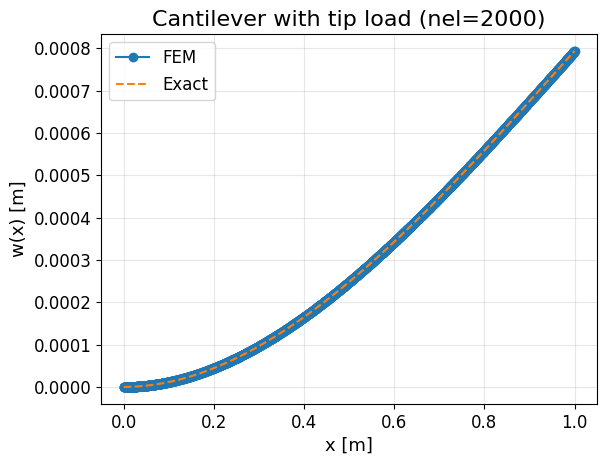

In [25]:
from scipy.linalg import cho_factor, cho_solve
def solve_cantilever_tip(E=210e9, I=1e-6, L=1.0, nel=2000, P=500.0, use_quadrature=False):
    K, F, Le = assemble_beam(E, I, L, nel, q_uniform=0.0, P_tip=P,
                             use_quadrature=use_quadrature)
    ndof = len(F)

    # Clamp at left: fix w0, th0
    fixed = np.array([0,1])
    free  = np.setdiff1d(np.arange(ndof), fixed)

    # Partition
    Kff = K[np.ix_(free, free)]
    Ff  = F[free]

    # Solve
    # Uf = np.linalg.solve(Kff, Ff)
    c, lower = cho_factor(Kff)
    Uf = cho_solve((c, lower), Ff)

    U  = np.zeros(ndof)
    U[free] = Uf

    # Extract nodal fields
    x = np.linspace(0, L, nel+1)
    w = U[0::2]
    th = U[1::2]

    # Exact solution
    EI = E*I
    w_exact = (P/(6*EI)) * x**2 * (3*L - x)

    # Tip error
    rel_err = abs(w[-1] - w_exact[-1]) / abs(w_exact[-1]) * 100

    print(f"Tip deflection FEM = {w[-1]:.6e} m")
    print(f"Tip deflection exact = {w_exact[-1]:.6e} m")
    print(f"Relative error at tip = {rel_err:.3e} %")

    # Plot
    plt.figure()
    plt.plot(x, w, "o-", label="FEM")
    plt.plot(x, w_exact, "--", label="Exact")
    plt.xlabel("x [m]")
    plt.ylabel("w(x) [m]")
    plt.title(f"Cantilever with tip load (nel={nel})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return x, w, th, w_exact

# Quick run
_ = solve_cantilever_tip()


## 8) Convergence study (tip deflection error vs. number of elements)

A hallmark of FEM is **convergence** as the mesh is refined.
For the cantilever with tip load:

- With just one cubic Hermite element, the solution is **exact** 
  (since the analytical $w(x)$ is cubic in $x$).
- With more elements, the solution is also exact up to roundoff.
- Nevertheless, it is useful to compute and plot the error as `nel` increases,
  confirming the consistency of our implementation.


nel	Relative tip error
1	6.830e-16
2	9.563e-16
4	2.732e-16
8	6.762e-14
16	9.227e-13
20	1.427e-11


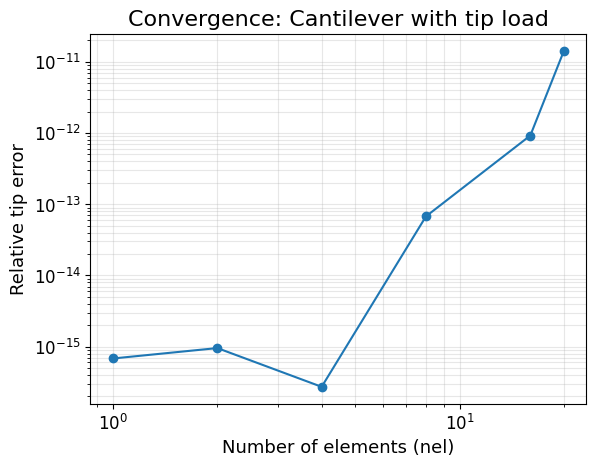

In [28]:
def convergence_study(E=210e9, I=1e-6, L=1.0, P=1000.0, nels=(1,2,4,8,16,20)):
    errs = []
    for nel in nels:
        K,F,Le = assemble_beam(E,I,L,nel,q_uniform=0.0,P_tip=P)
        ndof=len(F)
        fixed=[0,1]
        free=[i for i in range(ndof) if i not in fixed]
        Kff=K[np.ix_(free,free)]
        Ff=F[free]
        # Uf=np.linalg.solve(Kff,Ff)
        c, lower = cho_factor(Kff)
        Uf = cho_solve((c, lower), Ff)
        U=np.zeros(ndof);U[free]=Uf
        w_tip=U[-2]
        w_tip_exact = P*L**3/(3*E*I)
        errs.append(abs(w_tip - w_tip_exact)/abs(w_tip_exact))
    print("nel\tRelative tip error")
    for nel, err in zip(nels, errs):
        print(f"{nel}\t{err:.3e}")
    plt.figure()
    plt.loglog(nels, errs, "o-")
    plt.xlabel("Number of elements (nel)")
    plt.ylabel("Relative tip error")
    plt.title("Convergence: Cantilever with tip load")
    plt.grid(True, which="both", alpha=0.3)
    plt.show()
    return np.array(nels), np.array(errs)

# Quick run
_ = convergence_study()


## Appendix — Building the element stiffness **k_e** and load **f_e** step-by-step

We work on one element of length $L_e$ with local coordinate $\xi \in [0,1]$, mapped by
$$
x(\xi) = x_1 + \xi\,L_e, \qquad dx = L_e\,d\xi.
$$

The Hermite cubic interpolation (DOFs $[w_1,\theta_1,w_2,\theta_2]$):
$$
w(\xi) = N_1 w_1 + N_2 \theta_1 + N_3 w_2 + N_4 \theta_2,
$$
with
$$
\begin{aligned}
N_1 &= 1 - 3\xi^2 + 2\xi^3, \\
N_2 &= L_e\,(\xi - 2\xi^2 + \xi^3), \\
N_3 &= 3\xi^2 - 2\xi^3, \\
N_4 &= L_e\,(-\xi^2 + \xi^3).
\end{aligned}
$$

Curvature (bending strain) $\kappa = w''(x)$ is linear in DOFs via
$$
\kappa(\xi) = B(\xi)\,u_e, \quad
B(\xi)=\Big[\tfrac{-6+12\xi}{L_e^2},\; \tfrac{-4+6\xi}{L_e},\; \tfrac{6-12\xi}{L_e^2},\; \tfrac{-2+6\xi}{L_e}\Big].
$$

---

### A) Stiffness matrix \(k_e\)

By strain energy / virtual work:
$$
k_e = \int_{0}^{L_e} B(x)^\top\,E I\,B(x)\,dx
     = E I \int_{0}^{1} B(\xi)^\top B(\xi)\,(L_e\,d\xi).
$$

Each entry is
$$
(k_e)_{ij} = E I \int_0^{L_e} B_i(x) B_j(x)\,dx
           = E I \int_0^{1} B_i(\xi) B_j(\xi)\, (L_e\,d\xi).
$$

Below we compute **four** representative entries explicitly.

---

#### 1) Entry \((1,1)\)

Here $B_1(\xi) = \dfrac{-6+12\xi}{L_e^2}$:
$$
\begin{aligned}
(k_e)_{11}
&= E I \int_0^{1} \left(\frac{-6+12\xi}{L_e^2}\right)^2 (L_e\,d\xi)
= \frac{E I}{L_e^3}\int_0^1 (-6+12\xi)^2\,d\xi.\\
(-6+12\xi)^2 &= 36 - 144\xi + 144\xi^2,\\
\int_0^1 (-6+12\xi)^2\,d\xi &= 36 - 72 + 48 = 12.
\end{aligned}
$$
Therefore
$$
\boxed{(k_e)_{11} = \dfrac{12\,E I}{L_e^3}.}
$$

---

#### 2) Entry \((1,2)\)

$B_1(\xi) = \dfrac{-6+12\xi}{L_e^2}$, $B_2(\xi) = \dfrac{-4+6\xi}{L_e}$:
$$
\begin{aligned}
(k_e)_{12}
&= E I \int_0^{1} \frac{-6+12\xi}{L_e^2}\,\frac{-4+6\xi}{L_e}\,(L_e\,d\xi)
= \frac{E I}{L_e^2}\int_0^1 (-6+12\xi)(-4+6\xi)\,d\xi.\\
(-6+12\xi)(-4+6\xi) &= 24 - 84\xi + 72\xi^2,\\
\int_0^1 (\cdot)\,d\xi &= 24 - 42 + 24 = 6.
\end{aligned}
$$
Thus
$$
\boxed{(k_e)_{12} = \dfrac{6\,E I}{L_e^2} \;=\; \dfrac{E I}{L_e^3}(6L_e).}
$$

---

#### 3) Entry \((2,2)\)

$B_2(\xi) = \dfrac{-4+6\xi}{L_e}$:
$$
\begin{aligned}
(k_e)_{22}
&= E I \int_0^{1} \left(\frac{-4+6\xi}{L_e}\right)^2 (L_e\,d\xi)
= \frac{E I}{L_e}\int_0^1 (16 - 48\xi + 36\xi^2)\,d\xi \\
&= \frac{E I}{L_e}\,(16 - 24 + 12) = \frac{4\,E I}{L_e}
= \frac{E I}{L_e^3}(4L_e^2).
\end{aligned}
$$
So
$$
\boxed{(k_e)_{22} = \dfrac{4\,E I}{L_e} \;=\; \dfrac{E I}{L_e^3}(4L_e^2).}
$$

---

#### 4) Entry \((1,3)\)

$B_1(\xi) = \dfrac{-6+12\xi}{L_e^2}$, $B_3(\xi) = \dfrac{6-12\xi}{L_e^2}$:
$$
\begin{aligned}
(k_e)_{13}
&= E I \int_0^{1} \frac{-6+12\xi}{L_e^2}\,\frac{6-12\xi}{L_e^2}\,(L_e\,d\xi)
= \frac{E I}{L_e^3}\int_0^1 (-6+12\xi)(6-12\xi)\,d\xi.\\
(-6+12\xi)(6-12\xi) &= -36 + 144\xi - 144\xi^2,\\
\int_0^1 (\cdot)\,d\xi &= -36 + 72 - 48 = -12.
\end{aligned}
$$
Hence
$$
\boxed{(k_e)_{13} = -\,\dfrac{12\,E I}{L_e^3}.}
$$

By symmetry you can fill the remaining entries. The final matrix is
$$
\boxed{
k_e = \frac{E I}{L_e^3}
\begin{bmatrix}
 12 &  6L_e & -12 &  6L_e \\
  6L_e & 4L_e^2 & -6L_e & 2L_e^2 \\
 -12 & -6L_e &  12 & -6L_e \\
  6L_e & 2L_e^2 & -6L_e & 4L_e^2
\end{bmatrix}.
}
$$

---

### B) Consistent load vector \(f_e\) (uniform \(q\))

Definition:
$$
f_e = \int_0^{L_e} N^\top(x)\, q(x)\, dx, \qquad N=[N_1,N_2,N_3,N_4].
$$
For uniform $q(x)\equiv q$,
$$
(f_e)_i = q \int_0^{L_e} N_i(x)\,dx = q\,L_e \int_0^1 N_i(\xi)\,d\xi.
$$

Compute **all four** components:

1) $(f_e)_1$ for $N_1=1-3\xi^2+2\xi^3$:
$$
\int_0^1 (1-3\xi^2+2\xi^3)\,d\xi = 1 - 1 + \tfrac12 = \tfrac12
\;\Rightarrow\;
\boxed{(f_e)_1 = \dfrac{q L_e}{2}.}
$$

2) $(f_e)_2$ for $N_2=L_e(\xi-2\xi^2+\xi^3)$:
$$
\int_0^1 L_e(\xi-2\xi^2+\xi^3)\,d\xi = L_e\Big(\tfrac12 - \tfrac{2}{3} + \tfrac14\Big) = L_e\cdot \tfrac{1}{12}
\;\Rightarrow\;
\boxed{(f_e)_2 = \dfrac{q L_e^2}{12}.}
$$

3) $(f_e)_3$ for $N_3=3\xi^2-2\xi^3$:
$$
\int_0^1 (3\xi^2-2\xi^3)\,d\xi = 1 - \tfrac12 = \tfrac12
\;\Rightarrow\;
\boxed{(f_e)_3 = \dfrac{q L_e}{2}.}
$$

4) $(f_e)_4$ for $N_4=L_e(-\xi^2+\xi^3)$:
$$
\int_0^1 L_e(-\xi^2+\xi^3)\,d\xi = L_e\Big(-\tfrac{1}{3} + \tfrac{1}{4}\Big) = -\,\frac{L_e}{12}
\;\Rightarrow\;
\boxed{(f_e)_4 = -\,\dfrac{q L_e^2}{12}.}
$$

Collecting,
$$
\boxed{
f_e =
\begin{bmatrix}
qL_e/2 \\
qL_e^2/12 \\
qL_e/2 \\
-\,qL_e^2/12
\end{bmatrix}
=
\frac{qL_e}{2}\,
\begin{bmatrix}
1 \\[2pt] L_e/6 \\[2pt] 1 \\[2pt] -\,L_e/6
\end{bmatrix}.
}
$$
